In [ ]:
# Step 1: Import Required Libraries

In [22]:
import pandas as pd # loading data
import numpy as np # mathematical calculations
import re # regular expressions for cleaning the data
import nltk # for basic
import matplotlib.pyplot as plt # visualization
from nltk.corpus import stopwords # to remove be verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer # for sentiment analysis
from collections import Counter
from wordcloud import WordCloud
import string



# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [11]:
# Step 2: Create Sample Customer Feedback

In [23]:
data = {
    "Feedback": [
        "The food was delicious and arrived on time.",
        "Delivery was very late and the food was cold.",
        "Great packaging and excellent customer service.",
        "Food quality was poor and overpriced.",
        "The meal was okay, nothing special but not bad either.",
        "Amazing taste and generous portion sizes.",
        "The restaurant forgot one of my items and support was unhelpful.",
        "Delivery arrived within the expected time and the food was acceptable.",
        "Excellent service, fresh ingredients, and reasonable pricing.",
        "The packaging was damaged, but the food quality was decent."
    ],
}

# Create DataFrame
df = pd.DataFrame(data)

# Display first few rows
print("Customer Feedback Dataset:")
print(df.head())


Customer Feedback Dataset:
                                            Feedback
0        The food was delicious and arrived on time.
1      Delivery was very late and the food was cold.
2    Great packaging and excellent customer service.
3              Food quality was poor and overpriced.
4  The meal was okay, nothing special but not bad...


In [ ]:
# Step 3: Data Cleaning and  Preprocessing

In [24]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

       # convert to lowercase
       text = text.lower()
       print('lower case', text)

       # remove special characters and numbers
       text=re.sub(r'[^a-zA-Z\s]', '', text)
       print('special character', text)

       #Tokenization
       words= word_tokenize(text)
       print('tokenization', words)

       # Remove stopwords
       words = [word for word in words if word not in stop_words]
       print('stopwords', words)

       # Join words again
       cleaned_text = ' '.join(words)
       return cleaned_text

# Apply cleaning function
df['Cleaned_Feedback'] = df['Feedback'].apply(clean_text)

# Display cleanedFeedback
print("\nCleaned Feedback:")
print(df[['Feedback', 'Cleaned_Feedback']])

lower case the food was delicious and arrived on time.
special character the food was delicious and arrived on time
tokenization ['the', 'food', 'was', 'delicious', 'and', 'arrived', 'on', 'time']
stopwords ['food', 'delicious', 'arrived', 'time']
lower case delivery was very late and the food was cold.
special character delivery was very late and the food was cold
tokenization ['delivery', 'was', 'very', 'late', 'and', 'the', 'food', 'was', 'cold']
stopwords ['delivery', 'late', 'food', 'cold']
lower case great packaging and excellent customer service.
special character great packaging and excellent customer service
tokenization ['great', 'packaging', 'and', 'excellent', 'customer', 'service']
stopwords ['great', 'packaging', 'excellent', 'customer', 'service']
lower case food quality was poor and overpriced.
special character food quality was poor and overpriced
tokenization ['food', 'quality', 'was', 'poor', 'and', 'overpriced']
stopwords ['food', 'quality', 'poor', 'overpriced']
lo

In [6]:
# Step 4: Sentiment Analysis

In [25]:
sia=SentimentIntensityAnalyzer()

def analyze_sentiment(Feedback):
    score = sia.polarity_scores(Feedback)

    compound = score['compound']

    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment Analysis
df['sentiment'] = df['Cleaned_Feedback'].apply(analyze_sentiment)

# Display sentiment analysis results
print("\nSentiment Analysis Results:")
print(df[['Feedback', 'sentiment']])


Sentiment Analysis Results:
                                            Feedback sentiment
0        The food was delicious and arrived on time.  Positive
1      Delivery was very late and the food was cold.   Neutral
2    Great packaging and excellent customer service.  Positive
3              Food quality was poor and overpriced.  Negative
4  The meal was okay, nothing special but not bad...  Positive
5          Amazing taste and generous portion sizes.  Positive
6  The restaurant forgot one of my items and supp...  Positive
7  Delivery arrived within the expected time and ...  Positive
8  Excellent service, fresh ingredients, and reas...  Positive
9  The packaging was damaged, but the food qualit...  Negative


In [ ]:
# step 5: Find Common Keywords

In [26]:
all_words =" ".join(df['Cleaned_Feedback'])
word_list = all_words.split()

# Count word frequency
word_freq= Counter(word_list)

# Display top 10 keywords
print("\nTop 10 Keywords:")
print(word_freq.most_common(10))


Top 10 Keywords:
[('food', 5), ('arrived', 2), ('time', 2), ('delivery', 2), ('packaging', 2), ('excellent', 2), ('service', 2), ('quality', 2), ('delicious', 1), ('late', 1)]


In [ ]:
# Step 6: Identify Common Complaints

In [27]:
negative_Feedback = df[df['sentiment'] == 'Negative']
negative_words = " ".join(negative_Feedback['Cleaned_Feedback'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)

# Display top 10 common complaints
print("\nTop 10 Common Complaints:")
print(complaint_freq.most_common(10))



Top 10 Common Complaints:
[('food', 2), ('quality', 2), ('poor', 1), ('overpriced', 1), ('packaging', 1), ('damaged', 1), ('decent', 1)]


In [ ]:
# Step 7:Visualization

In [28]:
sentiment_counts = df['sentiment'].value_counts()
sentiment_counts

,count
sentiment,
Positive,7
Negative,2
Neutral,1


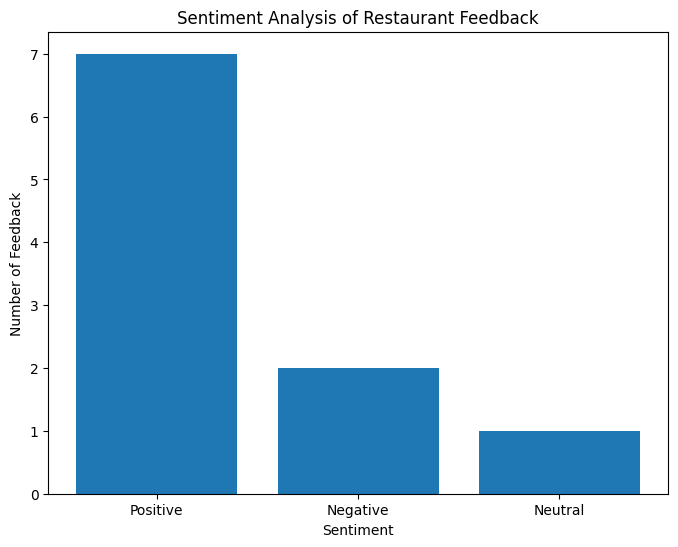

In [29]:
sentiment_counts = df['sentiment'].value_counts() # it will give category count

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Sentiment Analysis of Restaurant Feedback')
plt.xlabel('Sentiment')
plt.ylabel('Number of Feedback')
plt.show()

In [ ]:
# Step 8: Generate Word Cloud

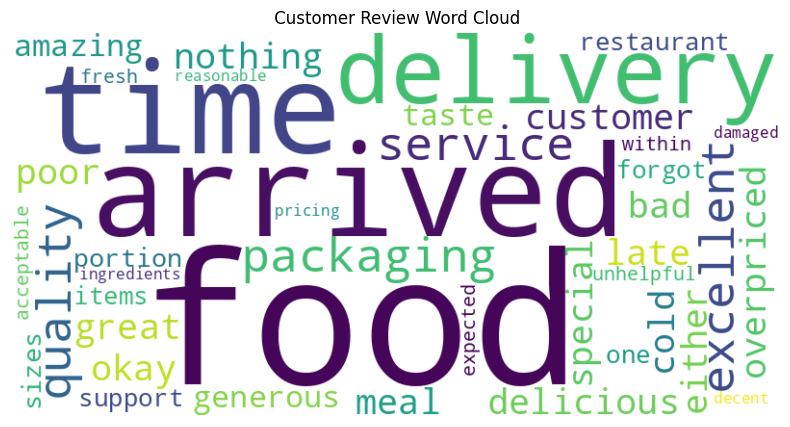

In [30]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
    ).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(' Customer Review Word Cloud')
plt.show()